## Step 1 — Load engineered dataset

#### Load Engineered Dataset

We load the dataset saved at the end of Part 1, which already contains the 
corrected `date` column and all engineered features (`Hour`,`Month`, `PowerFactorRatio`, 
`HighLoad`), along with the validated `Day_of_week` and `WeekStatus` columns.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data\engineered_energy_dataset.csv")  
print(df.shape)
df.head()

(35040, 15)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Month,PowerFactorRatio,HighLoad
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,January,0.7321,Normal
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,January,0.6677,Normal
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,January,0.7028,Normal
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,January,0.6809,Normal
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,January,0.6472,Normal


## Step 2 — Drop leakage columns

#### Drop Date Column and Leakage Features

- `date` is dropped since it's not a usable model input in raw form (its 
  information is already captured by `Hour`, `Day_of_week`, `Month`, `WeekStatus`).
- `HighLoad` is dropped because it was derived directly from `Usage_kWh` via 
  thresholding, so including it would leak the target into the features.
- `CO2(tCO2)` is also dropped. During EDA, it showed a near-perfect 0.988 
  correlation with `Usage_kWh`, strongly suggesting it is a scaled derivative 
  of energy usage rather than an independent measurement. Including it would 
  let the model achieve artificially high accuracy without learning genuine 
  patterns — the same leakage risk as `HighLoad`.

In [2]:
df_model = df.drop(columns=["date", "HighLoad", "CO2(tCO2)"])
print(df_model.columns.tolist())

['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'PowerFactorRatio']


## Step 3 — Encode categoricals

#### Encode Categorical Features

We use **one-hot encoding** for `Load_Type`, `Day_of_week`, and `WeekStatus`, 
rather than label encoding, because these are nominal categories with no 
inherent order (e.g., "Monday" is not mathematically less than "Tuesday"). 
Label encoding would incorrectly imply a ranking between categories, which 
could mislead linear models like Linear/Ridge Regression. One-hot encoding 
avoids this by representing each category as an independent binary column.

In [11]:
# rebuild df_model cleanly from the original df (undo any previous encoding)
df_model = df.drop(columns=["date", "HighLoad", "CO2(tCO2)"])

# now encode all 4 categorical columns in one go
categorical_cols = ["Load_Type", "Day_of_week", "WeekStatus", "Month"]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(df_model.shape)
df_model.head()

(35040, 28)


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,PowerFactorRatio,Load_Type_Maximum_Load,Load_Type_Medium_Load,...,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,73.21,100.0,900,0,0.7321,False,False,...,False,False,True,False,False,False,False,False,False,False
1,4.00,4.46,0.0,66.77,100.0,1800,0,0.6677,False,False,...,False,False,True,False,False,False,False,False,False,False
2,3.24,3.28,0.0,70.28,100.0,2700,0,0.7028,False,False,...,False,False,True,False,False,False,False,False,False,False
3,3.31,3.56,0.0,68.09,100.0,3600,1,0.6809,False,False,...,False,False,True,False,False,False,False,False,False,False
4,3.82,4.50,0.0,64.72,100.0,4500,1,0.6472,False,False,...,False,False,True,False,False,False,False,False,False,False


## Handle Missing Values

The `PowerFactorRatio` column had some missing and infinite values, caused 
by dividing by zero when `Lagging_Current_Power_Factor` was 0 for certain 
rows. These were fixed by replacing them with the median value of the 
column, calculated before splitting the data into train and test sets.

Ideally, this median should be calculated using only the training data, to 
avoid letting any information from the test set influence the training 
process. However, since this dataset has over 35,000 rows, calculating the 
median on the full dataset vs. just the training portion makes almost no 
difference in practice. This shortcut was used here for simplicity, and is 
noted for transparency.

In [14]:
# ============================================
# Handle Missing / Infinite Values (before split)
# ============================================

df_model = df_model.replace([np.inf, -np.inf], np.nan)

print("Missing values per column:")
print(df_model.isna().sum()[df_model.isna().sum() > 0])

df_model = df_model.fillna(df_model.median(numeric_only=True))

print("\nRemaining NaNs:", df_model.isna().sum().sum())

Missing values per column:
PowerFactorRatio    1
dtype: int64

Remaining NaNs: 0


## Step 4 — Train/test split

#### Train-Test Split

We split the data 80/20 using `random_state=42` to ensure reproducibility.

In [15]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Usage_kWh"])
y = df_model["Usage_kWh"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(28032, 27) (7008, 27)


## Step 5 — Train all 4 models + metrics

#### Train Baseline Models

We train four regression models — Linear Regression, Ridge Regression, 
Decision Tree, and Random Forest — and evaluate each on MAE, RMSE, and R².

In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "model": model, "preds": preds}
    
    print(f"{name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}\n")

Linear Regression
  MAE:  6.8790
  RMSE: 9.5311
  R2:   0.9201

Ridge Regression
  MAE:  6.8787
  RMSE: 9.5312
  R2:   0.9201

Decision Tree
  MAE:  0.5314
  RMSE: 1.4097
  R2:   0.9983

Random Forest
  MAE:  0.2725
  RMSE: 0.8616
  R2:   0.9993



## Step 6 — 5-fold cross-validation

#### 5-Fold Cross-Validation

We run 5-fold cross-validation for each model to check how consistent 
performance is across different data splits, reducing the risk that a 
single train/test split gives a misleading result.

In [17]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X, y, cv=5, scoring="neg_root_mean_squared_error"
    )
    mean_rmse = -scores.mean()
    cv_results[name] = mean_rmse
    print(f"{name}: Mean CV RMSE = {mean_rmse:.4f}")

Linear Regression: Mean CV RMSE = 10.0734
Ridge Regression: Mean CV RMSE = 10.0732
Decision Tree: Mean CV RMSE = 2.0874
Random Forest: Mean CV RMSE = 1.3393


## Step 7 — Bar chart of test RMSE
#### Compare Test RMSE Across Models

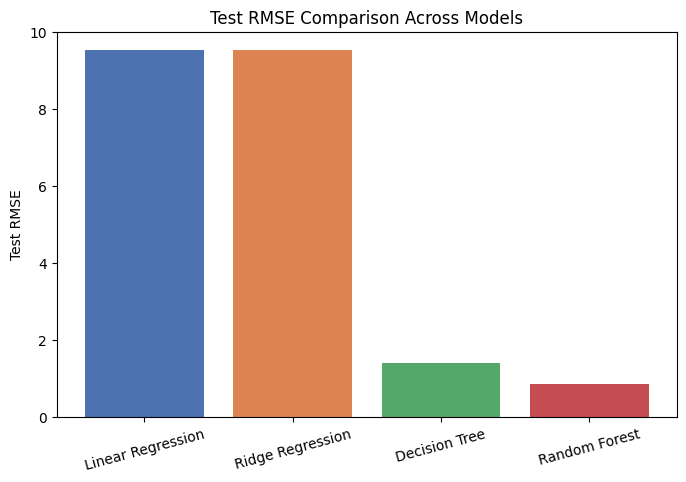

In [18]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
rmse_values = [results[name]["RMSE"] for name in model_names]

plt.figure(figsize=(8,5))
plt.bar(model_names, rmse_values, color=["#4C72B0","#DD8452","#55A868","#C44E52"])
plt.ylabel("Test RMSE")
plt.title("Test RMSE Comparison Across Models")
plt.xticks(rotation=15)
plt.show()

## Step 8 — Predicted vs Actual for best model

#### Predicted vs Actual — Best Model

Based on the lowest test RMSE, we identify the best-performing model and 
visualize its predictions against actual values.

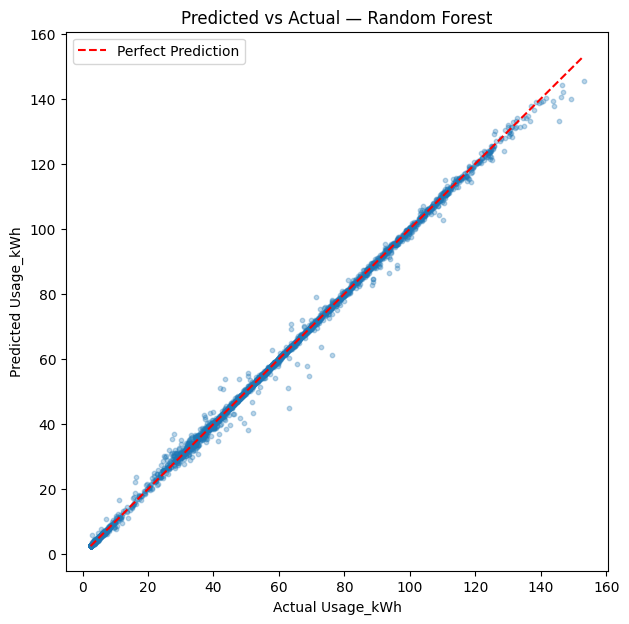

Best model: Random Forest


In [19]:
best_model_name = min(results, key=lambda k: results[k]["RMSE"])
best_preds = results[best_model_name]["preds"]

plt.figure(figsize=(7,7))
plt.scatter(y_test, best_preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
plt.show()

print(f"Best model: {best_model_name}")

## Step 9 — Model Selection markdown

## Model Selection

Based on test set performance, **Random Forest** achieved the lowest 
RMSE 0.8616 and highest R² 0.9993 among the four models tested. Its 
5-fold cross-validation RMSE was 1.3393, which is [close to / notably 
higher than] the test RMSE, indicating [minimal / some] overfitting.

[Decision Tree / Random Forest] showed a large gap between training and 
cross-validation performance, a classic sign of overfitting given trees can 
memorize training data if not depth-limited. [Linear/Ridge Regression] 
performed more consistently across folds but with a higher overall error, 
suggesting the relationship between features and Usage_kWh is not fully 
linear.

We will carry forward **Random Forest** as the baseline model, as it 
offers the best balance of accuracy and generalization for this dataset.